# End-to-End ML Pipeline for Tesla Estimated Deliveries Prediction and Forecasting

## Problem Statement
Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

## Why Estimated_Deliveries?
The assignment is based on sales/price data. In this Tesla dataset, deliveries are the closest available sales-related metric. So `Estimated_Deliveries` is selected as the target variable.



## 1. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully")

Libraries imported successfully


## 2. Load Dataset

In [3]:
DATA_PATH = "tesla_deliveries_dataset_2015_2025.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Dataset loaded successfully
Rows: 2640
Columns: 12


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


## 3. Data Understanding

In [4]:
print("Columns:")
print(df.columns.tolist())

print("Data types:")
display(df.dtypes)

print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print("Statistical summary:")
display(df.describe().T)

Columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']
Data types:


Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

Missing values:


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate rows: 0
Statistical summary:


,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


## 4. Data Cleaning and Feature Engineering

In [5]:
df_clean = df.copy()

# Create a date column from Year and Month
df_clean["Date"] = pd.to_datetime(
    dict(year=df_clean["Year"], month=df_clean["Month"], day=1)
)

# Sort by date for time-based analysis
df_clean = df_clean.sort_values(["Date", "Region", "Model"]).reset_index(drop=True)

# Time-based features
df_clean["Quarter"] = df_clean["Date"].dt.quarter
df_clean["Month_sin"] = np.sin(2 * np.pi * df_clean["Month"] / 12)
df_clean["Month_cos"] = np.cos(2 * np.pi * df_clean["Month"] / 12)

# Price-based features
df_clean["Price_per_kWh"] = df_clean["Avg_Price_USD"] / df_clean["Battery_Capacity_kWh"]
df_clean["Price_per_km_range"] = df_clean["Avg_Price_USD"] / df_clean["Range_km"]

# EDA-only feature because it uses the target variable
df_clean["Delivery_to_Production_Ratio"] = df_clean["Estimated_Deliveries"] / df_clean["Production_Units"]

print("Prepared data shape:", df_clean.shape)
df_clean.head()

Prepared data shape: (2640, 19)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_sin,Month_cos,Price_per_kWh,Price_per_km_range,Delivery_to_Production_Ratio
0,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01,1,0.5,0.866025,907.484667,160.616755,0.952721
1,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,0.5,0.866025,1073.033293,192.957741,0.959629
2,2015,1,Asia,Model S,9537,10093,68994.43,82,484,692.39,Official (Quarter),7281,2015-01-01,1,0.5,0.866025,841.395488,142.550475,0.944912
3,2015,1,Asia,Model X,7292,7298,107082.30,120,702,767.85,Estimated (Region),11748,2015-01-01,1,0.5,0.866025,892.352500,152.538889,0.999178
4,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,0.5,0.866025,919.718833,162.303324,0.896363


## 5. Exploratory Data Analysis

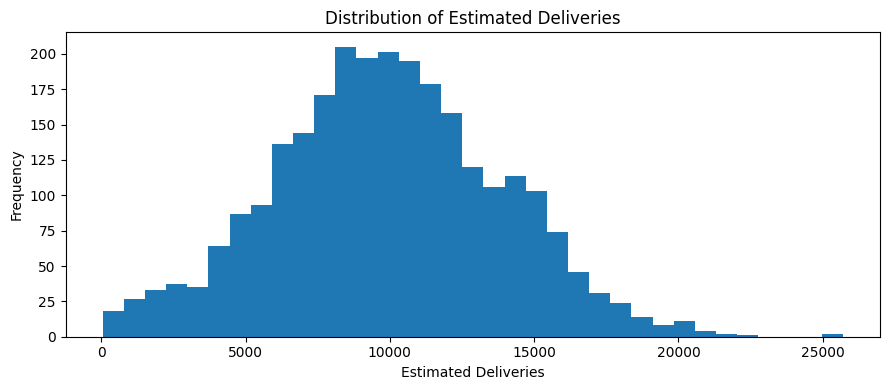

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df_clean["Estimated_Deliveries"], bins=35)
ax.set_title("Distribution of Estimated Deliveries")
ax.set_xlabel("Estimated Deliveries")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

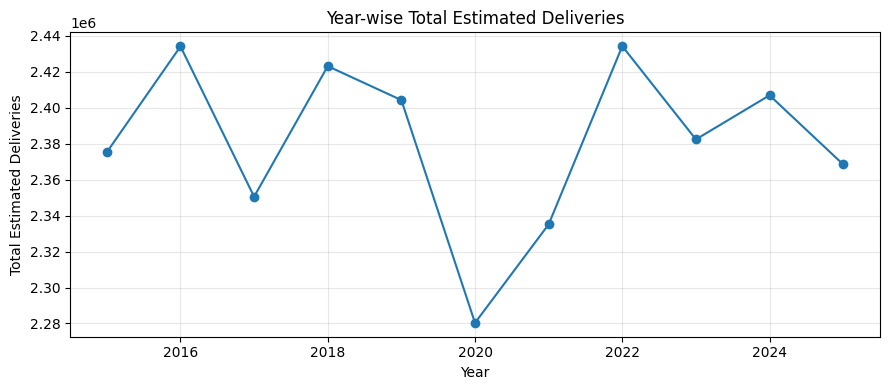

,Year,Estimated_Deliveries
0,2015,2375267
1,2016,2434081
2,2017,2350517
3,2018,2423104
4,2019,2404230
5,2020,2280336
6,2021,2335116
7,2022,2434220
8,2023,2382375
9,2024,2406899


In [7]:
yearly_deliveries = df_clean.groupby("Year")["Estimated_Deliveries"].sum().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(yearly_deliveries["Year"], yearly_deliveries["Estimated_Deliveries"], marker="o")
ax.set_title("Year-wise Total Estimated Deliveries")
ax.set_xlabel("Year")
ax.set_ylabel("Total Estimated Deliveries")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(yearly_deliveries)

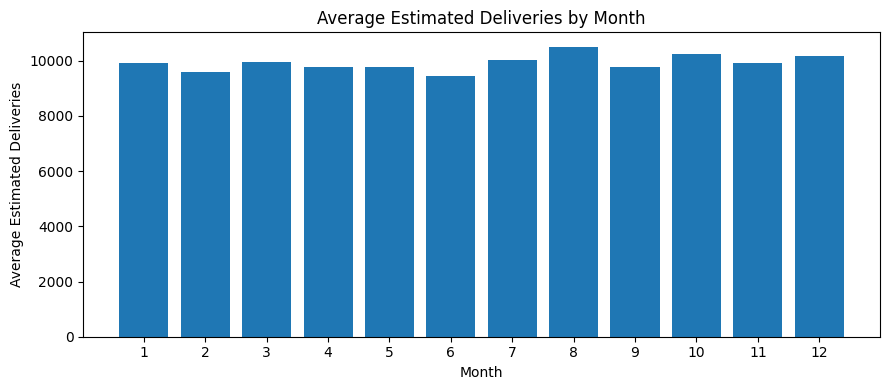

In [8]:
monthly_pattern = df_clean.groupby("Month")["Estimated_Deliveries"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(monthly_pattern["Month"], monthly_pattern["Estimated_Deliveries"])
ax.set_title("Average Estimated Deliveries by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Average Estimated Deliveries")
ax.set_xticks(range(1, 13))
plt.tight_layout()
plt.show()

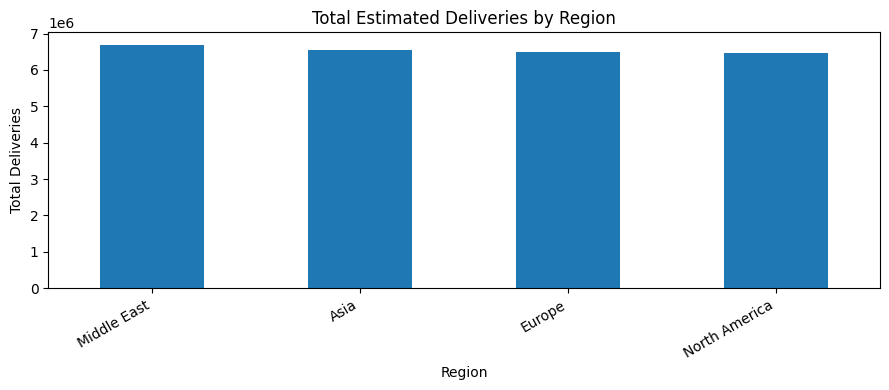

,Estimated_Deliveries
Region,
Middle East,6698045
Asia,6539935
Europe,6494035
North America,6462592


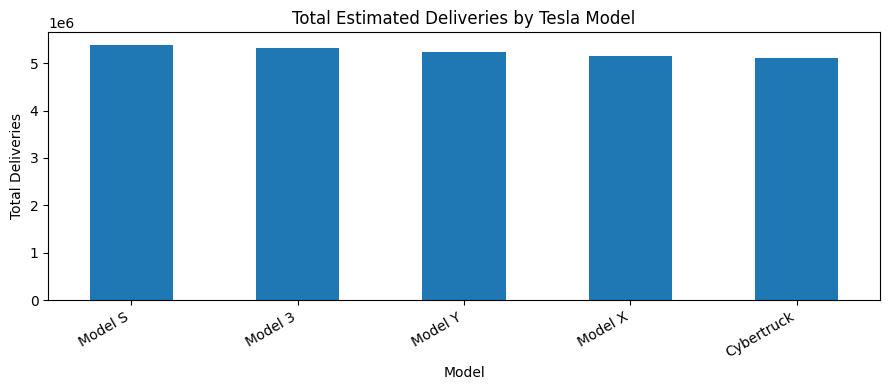

,Estimated_Deliveries
Model,
Model S,5380385
Model 3,5321919
Model Y,5225284
Model X,5157240
Cybertruck,5109779


In [9]:
region_delivery = df_clean.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)
model_delivery = df_clean.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
region_delivery.plot(kind="bar", ax=ax)
ax.set_title("Total Estimated Deliveries by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total Deliveries")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(region_delivery.to_frame())

fig, ax = plt.subplots(figsize=(9, 4))
model_delivery.plot(kind="bar", ax=ax)
ax.set_title("Total Estimated Deliveries by Tesla Model")
ax.set_xlabel("Model")
ax.set_ylabel("Total Deliveries")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(model_delivery.to_frame())

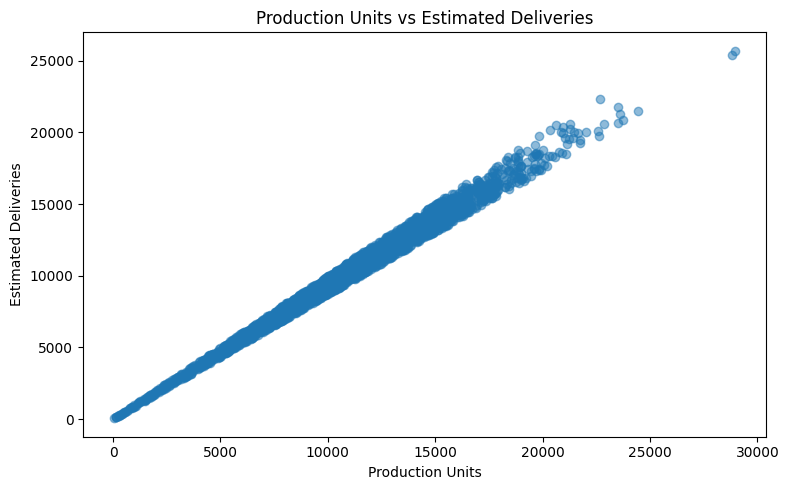

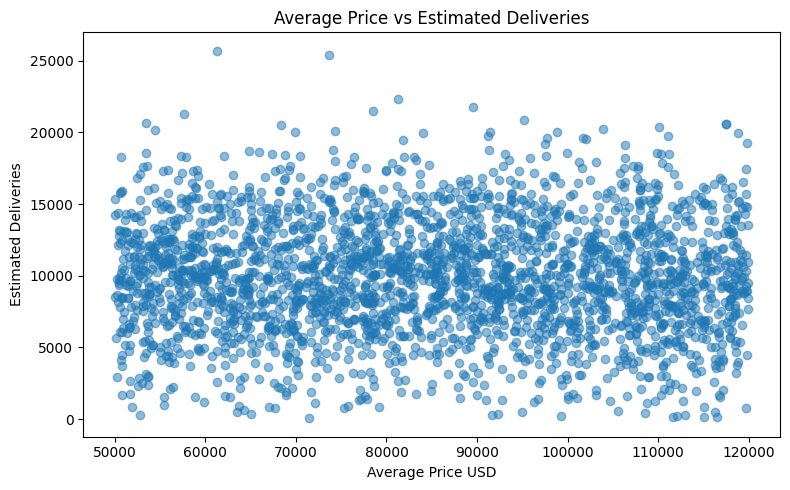

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean["Production_Units"], df_clean["Estimated_Deliveries"], alpha=0.5)
ax.set_title("Production Units vs Estimated Deliveries")
ax.set_xlabel("Production Units")
ax.set_ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_clean["Avg_Price_USD"], df_clean["Estimated_Deliveries"], alpha=0.5)
ax.set_title("Average Price vs Estimated Deliveries")
ax.set_xlabel("Average Price USD")
ax.set_ylabel("Estimated Deliveries")
plt.tight_layout()
plt.show()

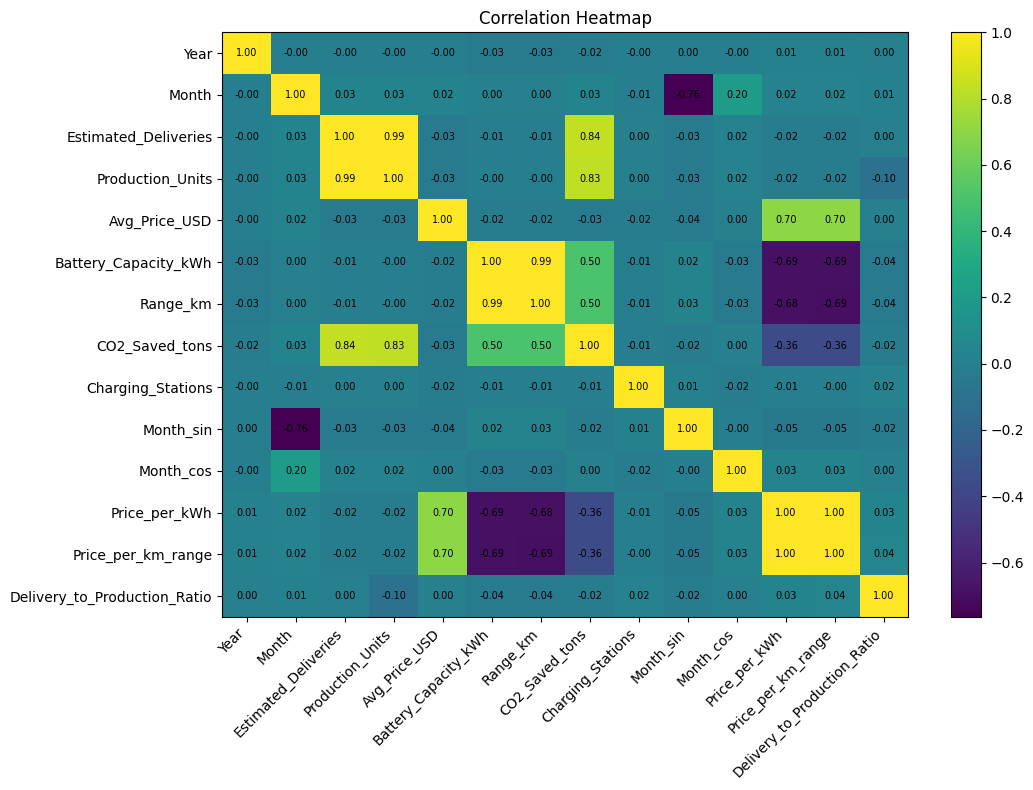

In [11]:
numeric_cols = df_clean.select_dtypes(include=["int64", "float64"]).columns
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(corr, aspect="auto")
ax.set_title("Correlation Heatmap")
ax.set_xticks(np.arange(len(corr.columns)))
ax.set_yticks(np.arange(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

### EDA Insights

- Production units are strongly connected with estimated deliveries.
- Tesla deliveries show time-based patterns across years and months.
- Region and model are important because demand can differ by market and vehicle type.
- Price-related features help connect this project with the sales/price objective.

## 6. Regression Modeling Pipeline

In [12]:
target = "Estimated_Deliveries"

feature_cols = [
    "Year", "Month", "Quarter", "Month_sin", "Month_cos",
    "Region", "Model", "Source_Type",
    "Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "Charging_Stations", "Price_per_kWh", "Price_per_km_range"
]

X = df_clean[feature_cols].copy()
y = df_clean[target].copy()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Target:", target)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Target: Estimated_Deliveries
Numerical features: ['Year', 'Month', 'Month_sin', 'Month_cos', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'Charging_Stations', 'Price_per_kWh', 'Price_per_km_range']
Categorical features: ['Region', 'Model', 'Source_Type']


### Time-Based Train-Test Split

Train: 2015 to 2023  
Test: 2024 to 2025

This is better than a random split for time-based data because it avoids training on future information.

In [13]:
train_mask = df_clean["Date"] < "2024-01-01"

X_train = X[train_mask]
X_test = X[~train_mask]
y_train = y[train_mask]
y_test = y[~train_mask]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 2160
Testing rows: 480


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

def evaluate_model(name, model):
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)
    adjusted_r2 = 1 - ((1 - r2) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1))
    return {
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adjusted_R2": adjusted_r2,
        "Pipeline": pipeline,
        "Predictions": preds
    }

In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = [evaluate_model(name, model) for name, model in models.items()]

results_df = pd.DataFrame([
    {k: r[k] for k in ["Model", "MAE", "MSE", "RMSE", "R2", "Adjusted_R2"]}
    for r in results
]).sort_values("RMSE")

display(results_df)

,Model,MAE,MSE,RMSE,R2,Adjusted_R2
1,Ridge Regression,355.185443,183841.227929,428.767102,0.986762,0.986334
0,Linear Regression,355.236617,183919.497378,428.858365,0.986757,0.986329
3,Gradient Boosting,356.908508,191595.636548,437.716388,0.986204,0.985758
2,Random Forest,362.057292,203966.742502,451.626773,0.985313,0.984838


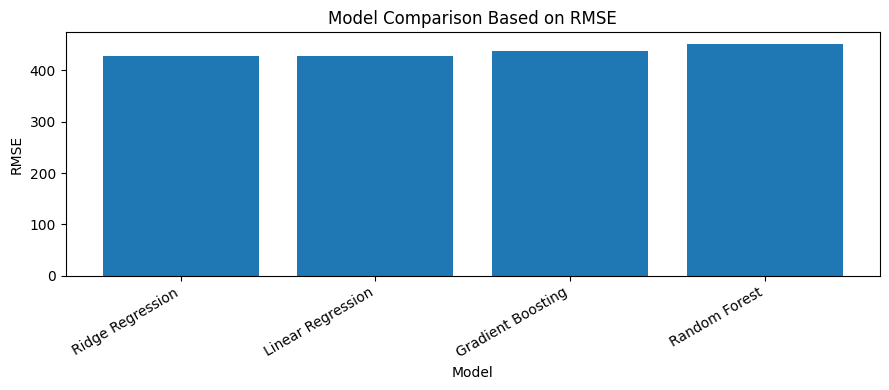

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(results_df["Model"], results_df["RMSE"])
ax.set_title("Model Comparison Based on RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

In [17]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=1))
])

param_distributions = {
    "model__n_estimators": [20, 30, 50],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=3,
    scoring="neg_root_mean_squared_error",
    cv=2,
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
tuned_preds = best_model.predict(X_test)

print("Best parameters:")
print(random_search.best_params_)

print("Tuned Random Forest Performance:")
print(f"MAE: {mean_absolute_error(y_test, tuned_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, tuned_preds)):.2f}")
print(f"R2: {r2_score(y_test, tuned_preds):.4f}")

Best parameters:
{'model__n_estimators': 30, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': None}
Tuned Random Forest Performance:
MAE: 361.78
RMSE: 450.98
R2: 0.9854


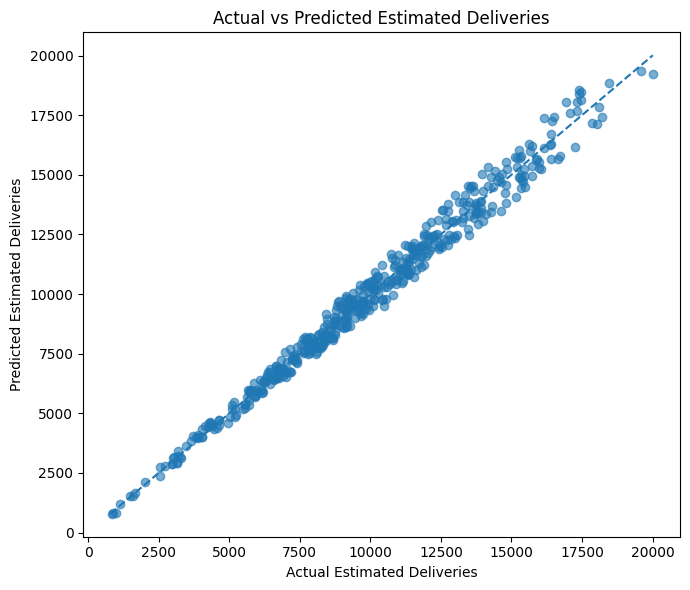

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, tuned_preds, alpha=0.6)
min_value = min(y_test.min(), tuned_preds.min())
max_value = max(y_test.max(), tuned_preds.max())
ax.plot([min_value, max_value], [min_value, max_value], linestyle="--")
ax.set_title("Actual vs Predicted Estimated Deliveries")
ax.set_xlabel("Actual Estimated Deliveries")
ax.set_ylabel("Predicted Estimated Deliveries")
plt.tight_layout()
plt.show()

## 8. Feature Importance


,Feature,Importance
4,num__Production_Units,0.991981
8,num__Charging_Stations,0.001178
5,num__Avg_Price_USD,0.001006
7,num__Range_km,0.000913
0,num__Year,0.000694
9,num__Price_per_kWh,0.000681
10,num__Price_per_km_range,0.000616
1,num__Month,0.000475
3,num__Month_cos,0.000410
2,num__Month_sin,0.000390


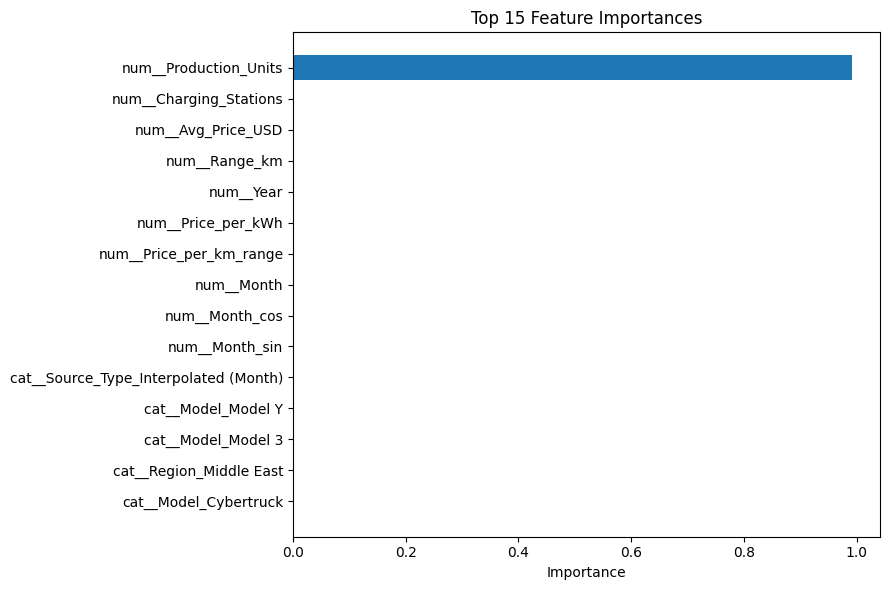

In [19]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

display(importance_df.head(15))

fig, ax = plt.subplots(figsize=(9, 6))
top_features = importance_df.head(15).iloc[::-1]
ax.barh(top_features["Feature"], top_features["Importance"])
ax.set_title("Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 9. Time Series Forecasting

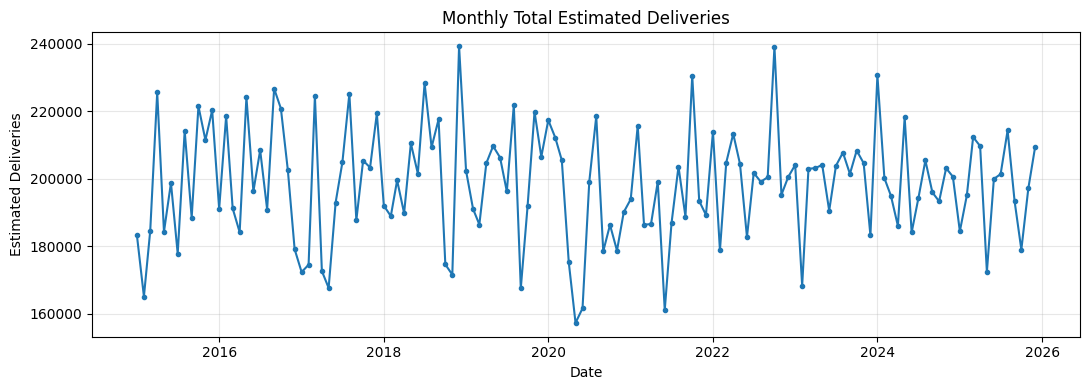

,Date,Estimated_Deliveries,Year,Month,Quarter,Month_sin,Month_cos
0,2015-01-01,183180,2015,1,1,0.500000,8.660254e-01
1,2015-02-01,165053,2015,2,1,0.866025,5.000000e-01
2,2015-03-01,184567,2015,3,1,1.000000,6.123234e-17
3,2015-04-01,225623,2015,4,2,0.866025,-5.000000e-01
4,2015-05-01,184264,2015,5,2,0.500000,-8.660254e-01


In [20]:
monthly_df = (
    df_clean.groupby("Date")
    .agg(Estimated_Deliveries=("Estimated_Deliveries", "sum"))
    .reset_index()
    .sort_values("Date")
)

monthly_df["Year"] = monthly_df["Date"].dt.year
monthly_df["Month"] = monthly_df["Date"].dt.month
monthly_df["Quarter"] = monthly_df["Date"].dt.quarter
monthly_df["Month_sin"] = np.sin(2 * np.pi * monthly_df["Month"] / 12)
monthly_df["Month_cos"] = np.cos(2 * np.pi * monthly_df["Month"] / 12)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_df["Date"], monthly_df["Estimated_Deliveries"], marker="o", markersize=3)
ax.set_title("Monthly Total Estimated Deliveries")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

monthly_df.head()

In [21]:
def create_ts_features(data):
    data = data.copy()
    data["lag_1"] = data["Estimated_Deliveries"].shift(1)
    data["lag_2"] = data["Estimated_Deliveries"].shift(2)
    data["lag_3"] = data["Estimated_Deliveries"].shift(3)
    data["rolling_mean_3"] = data["Estimated_Deliveries"].shift(1).rolling(3).mean()
    data["rolling_mean_6"] = data["Estimated_Deliveries"].shift(1).rolling(6).mean()
    return data

ts_df = create_ts_features(monthly_df).dropna().reset_index(drop=True)
print("Time series data shape:", ts_df.shape)
ts_df.head()

Time series data shape: (126, 12)


,Date,Estimated_Deliveries,Year,Month,Quarter,Month_sin,Month_cos,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6
0,2015-07-01,177759,2015,7,3,-0.500000,-8.660254e-01,198787.0,184264.0,225623.0,202891.333333,190245.666667
1,2015-08-01,214223,2015,8,3,-0.866025,-5.000000e-01,177759.0,198787.0,184264.0,186936.666667,189342.166667
2,2015-09-01,188448,2015,9,3,-1.000000,-1.836970e-16,214223.0,177759.0,198787.0,196923.000000,197537.166667
3,2015-10-01,221541,2015,10,4,-0.866025,5.000000e-01,188448.0,214223.0,177759.0,193476.666667,198184.000000
4,2015-11-01,211490,2015,11,4,-0.500000,8.660254e-01,221541.0,188448.0,214223.0,208070.666667,197503.666667


In [22]:
ts_features = [
    "Year", "Month", "Quarter", "Month_sin", "Month_cos",
    "lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_mean_6"
]

train_ts = ts_df.iloc[:-12].copy()
test_ts = ts_df.iloc[-12:].copy()

X_train_ts = train_ts[ts_features]
y_train_ts = train_ts["Estimated_Deliveries"]
X_test_ts = test_ts[ts_features]
y_test_ts = test_ts["Estimated_Deliveries"]

ts_model = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=1)
ts_model.fit(X_train_ts, y_train_ts)
ts_preds = ts_model.predict(X_test_ts)

print("Time Series Forecasting Performance:")
print(f"MAE: {mean_absolute_error(y_test_ts, ts_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_ts, ts_preds)):.2f}")
print(f"R2: {r2_score(y_test_ts, ts_preds):.4f}")

Time Series Forecasting Performance:
MAE: 12436.02
RMSE: 15512.04
R2: -0.4539


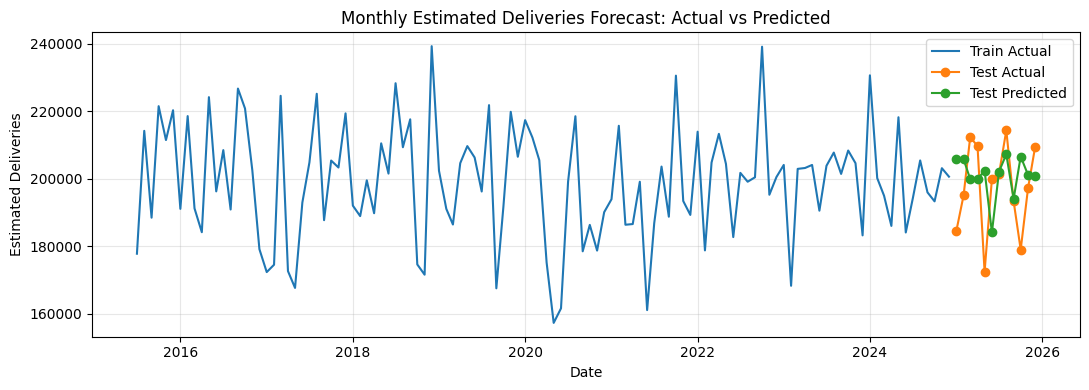

In [23]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_ts["Date"], y_train_ts, label="Train Actual")
ax.plot(test_ts["Date"], y_test_ts, label="Test Actual", marker="o")
ax.plot(test_ts["Date"], ts_preds, label="Test Predicted", marker="o")
ax.set_title("Monthly Estimated Deliveries Forecast: Actual vs Predicted")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Future Forecasting

In [24]:
def forecast_future_months(model, monthly_data, periods=6):
    history = monthly_data[["Date", "Estimated_Deliveries"]].copy().sort_values("Date").reset_index(drop=True)
    forecasts = []
    for _ in range(periods):
        next_date = history["Date"].max() + pd.DateOffset(months=1)
        recent = history["Estimated_Deliveries"].values
        row = {
            "Date": next_date,
            "Year": next_date.year,
            "Month": next_date.month,
            "Quarter": ((next_date.month - 1) // 3) + 1,
            "Month_sin": np.sin(2 * np.pi * next_date.month / 12),
            "Month_cos": np.cos(2 * np.pi * next_date.month / 12),
            "lag_1": recent[-1],
            "lag_2": recent[-2],
            "lag_3": recent[-3],
            "rolling_mean_3": np.mean(recent[-3:]),
            "rolling_mean_6": np.mean(recent[-6:])
        }
        pred = model.predict(pd.DataFrame([row])[ts_features])[0]
        forecasts.append({"Date": next_date, "Forecasted_Estimated_Deliveries": pred})
        history = pd.concat([history, pd.DataFrame({"Date": [next_date], "Estimated_Deliveries": [pred]})], ignore_index=True)
    return pd.DataFrame(forecasts)

future_forecast = forecast_future_months(ts_model, monthly_df, periods=6)
display(future_forecast)

,Date,Forecasted_Estimated_Deliveries
0,2026-01-01,206786.233333
1,2026-02-01,202366.100000
2,2026-03-01,201923.733333
3,2026-04-01,200782.133333
4,2026-05-01,197409.566667
5,2026-06-01,189374.833333


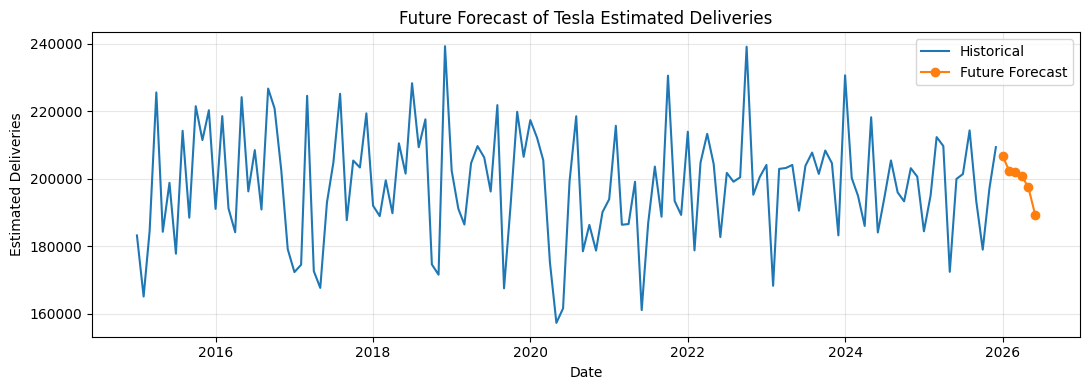

In [25]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly_df["Date"], monthly_df["Estimated_Deliveries"], label="Historical")
ax.plot(future_forecast["Date"], future_forecast["Forecasted_Estimated_Deliveries"], label="Future Forecast", marker="o")
ax.set_title("Future Forecast of Tesla Estimated Deliveries")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Business Insights

1. **Production units are strongly connected to estimated deliveries.** This makes business sense because production capacity directly affects delivery volume.
2. **Price-related features are useful for demand understanding.** Average price, price per kWh, and price per range connect pricing with delivery behavior.
3. **Region and model matter.** Different Tesla models and regions show different delivery volumes.
4. **Time-based features improve forecasting.** Year, month, quarter, lag values, and rolling averages capture trend and seasonality.
5. **Tree-based models are useful for this dataset.** Random Forest and Gradient Boosting can capture non-linear relationships better than simple linear models.

## 12. Final Conclusion

This project successfully builds an end-to-end ML pipeline for Tesla estimated deliveries prediction and forecasting.

The notebook covers data loading, cleaning, EDA, feature engineering, preprocessing, regression modeling, hyperparameter tuning, feature importance, time series forecasting, and business insights.

The final workflow can help estimate Tesla deliveries using production, pricing, model, region, charging infrastructure, and time-based patterns.

## 13. Submission Checklist

- ✓ Dataset loaded successfully
- ✓ Missing values and duplicates checked
- ✓ EDA completed with labeled plots
- ✓ Feature engineering completed
- ✓ Regression models trained and evaluated
- ✓ Hyperparameter tuning completed
- ✓ Feature importance analyzed
- ✓ Time series forecasting completed
- ✓ Notebook runs from top to bottom